# Student Study Hours to CGPA Prediction: Linear Regression Baseline

**Competition:** Student Study Hours to CGPA Prediction

**Notebook Focus:** Exploratory data analysis, polynomial feature engineering, and baseline regression modeling emphasizing Mean Squared Error (MSE) optimization.

**Author:** [Amey Thakur](https://www.kaggle.com/ameythakur20)

## Table of Contents

1. [Data Acquisition](#1)
2. [Data Inspection](#2)
3. [Data Cleaning](#3)
4. [EDA](#4)
5. [Feature Engineering](#5)
6. [Modeling](#6)
7. [Evaluation](#7)
8. [Conclusion](#8)
9. [References](#9)

<a id="1"></a>
## 1. Data Acquisition

Load train, test, and sample submission files. Verify file availability on the local disk through a staging validation table.

In [1]:
import kagglehub

# Download competition dataset
path = kagglehub.competition_download('student-study-hours-to-cgpa-prediction')
print("Path to dataset files:", path)

# Alternative CLI method
!kaggle competitions download -c student-study-hours-to-cgpa-prediction

Path to dataset files: /kaggle/input/competitions/student-study-hours-to-cgpa-prediction
100%|████████████████████████████████████████| 203k/203k [00:00<00:00, 74.8MB/s]



In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'sans-serif'
})

PALETTE = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
SEED = 42

print('[STATUS] Libraries loaded.')

[STATUS] Libraries loaded.


In [3]:
TRAIN_PATH = '/kaggle/input/competitions/student-study-hours-to-cgpa-prediction/train_dataset.csv'
TEST_PATH  = '/kaggle/input/competitions/student-study-hours-to-cgpa-prediction/test_dataset.csv'
SUB_PATH   = '/kaggle/input/competitions/student-study-hours-to-cgpa-prediction/sample_submission.csv'

staging = pd.DataFrame({
    'path': [TRAIN_PATH, TEST_PATH, SUB_PATH],
    'exists': [os.path.isfile(TRAIN_PATH), os.path.isfile(TEST_PATH), os.path.isfile(SUB_PATH)]
})
staging.style.applymap(
    lambda v: 'color: green; font-weight: bold' if v is True else 'color: red; font-weight: bold',
    subset=['exists']
)

,path,exists
0,/kaggle/input/competitions/student-study-hours-to-cgpa-prediction/train_dataset.csv,True
1,/kaggle/input/competitions/student-study-hours-to-cgpa-prediction/test_dataset.csv,True
2,/kaggle/input/competitions/student-study-hours-to-cgpa-prediction/sample_submission.csv,True


In [4]:
if not staging['exists'].all():
    TRAIN_PATH = '/kaggle/input/competitions/student-study-hours-to-cgpa-prediction/train_dataset.csv'
    TEST_PATH  = '/kaggle/input/competitions/student-study-hours-to-cgpa-prediction/test_dataset.csv'
    SUB_PATH   = '/kaggle/input/competitions/student-study-hours-to-cgpa-prediction/sample_submission.csv'

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)
sub_df   = pd.read_csv(SUB_PATH)

print(f'[STATUS] Train loaded: {train_df.shape[0]:,} rows x {train_df.shape[1]} cols')
print(f'[STATUS] Test loaded:  {test_df.shape[0]:,} rows x {test_df.shape[1]} cols')

[STATUS] Train loaded: 24,000 rows x 3 cols
[STATUS] Test loaded:  6,000 rows x 1 cols


<a id="2"></a>
## 2. Data Inspection

Profile the available columns, data types, and check for missing values to understand the initial state of the dataset.

In [5]:
summary = pd.DataFrame({
    'column': train_df.columns,
    'dtype': train_df.dtypes.values,
    'non_null': train_df.notnull().sum().values,
    'null_count': train_df.isnull().sum().values,
    'unique_count': train_df.nunique().values
})
summary

,column,dtype,non_null,null_count,unique_count
0,id,int64,24000,0,24000
1,Study_Hours,float64,24000,0,5429
2,CGPA,float64,24000,0,690


In [6]:
train_df.head(5)

,id,Study_Hours,CGPA
0,21754,18.55,4.78
1,252,26.93,5.89
2,22942,58.94,8.77
3,619,57.25,8.73
4,17091,53.52,9.55


In [7]:
print('[STATUS] Target variable (CGPA) statistical summary:')
pd.DataFrame(train_df['CGPA'].describe()).T

[STATUS] Target variable (CGPA) statistical summary:


,count,mean,std,min,25%,50%,75%,max
CGPA,24000.0,6.592297,1.406009,2.53,5.48,6.59,7.7,10.0


<a id="3"></a>
## 3. Data Cleaning

Validate duplicate records and inspect boundary conditions. The synthetic dataset is structurally solid, requiring minimal imputation.

In [8]:
n_dups = train_df.duplicated().sum()
print(f'[STATUS] Exact duplicate rows across all columns: {n_dups}')

invalid_cgpa = train_df[(train_df['CGPA'] < 0.0) | (train_df['CGPA'] > 10.0)].shape[0]
invalid_hours = train_df[(train_df['Study_Hours'] < 0.0)].shape[0]

checks = pd.DataFrame({
    'validation_rule': ['CGPA bounds (0.0 to 10.0)', 'Study_Hours >= 0'],
    'violations_found': [invalid_cgpa, invalid_hours],
    'status': ['PASS' if invalid_cgpa == 0 else 'FAIL', 'PASS' if invalid_hours == 0 else 'FAIL']
})
checks

[STATUS] Exact duplicate rows across all columns: 0


,validation_rule,violations_found,status
0,CGPA bounds (0.0 to 10.0),0,PASS
1,Study_Hours >= 0,0,PASS


<a id="4"></a>
## 4. EDA

Visualize continuous distributions and establish the bivariate relationship between study hours and academic performance.

In [9]:
feature_stats = pd.DataFrame(train_df[['Study_Hours', 'CGPA']].agg(['min', 'max', 'mean', 'median', 'std'])).T
feature_stats

,min,max,mean,median,std
Study_Hours,5.00,60.0,32.424104,32.42,15.842140
CGPA,2.53,10.0,6.592297,6.59,1.406009


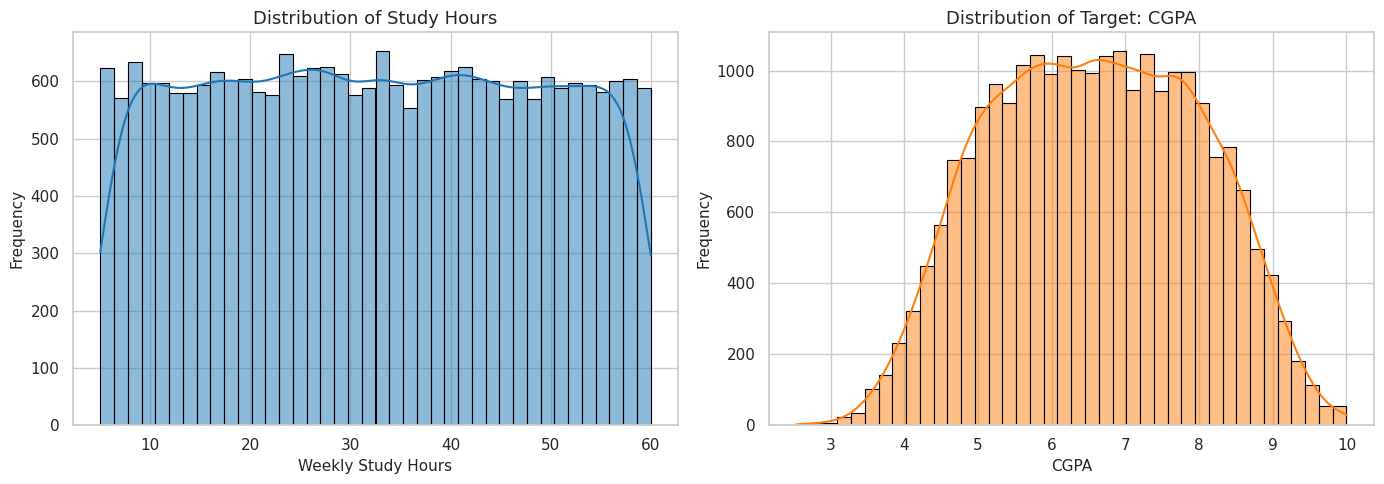

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    train_df['Study_Hours'], bins=40, kde=True, 
    color=PALETTE[0], edgecolor='black', ax=axes[0]
)
axes[0].set_title('Distribution of Study Hours')
axes[0].set_xlabel('Weekly Study Hours')
axes[0].set_ylabel('Frequency')

sns.histplot(
    train_df['CGPA'], bins=40, kde=True, 
    color=PALETTE[1], edgecolor='black', ax=axes[1]
)
axes[1].set_title('Distribution of Target: CGPA')
axes[1].set_xlabel('CGPA')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [11]:
corr_matrix = train_df[['Study_Hours', 'CGPA']].corr()
display(corr_matrix)

,Study_Hours,CGPA
Study_Hours,1.000000,0.903201
CGPA,0.903201,1.000000


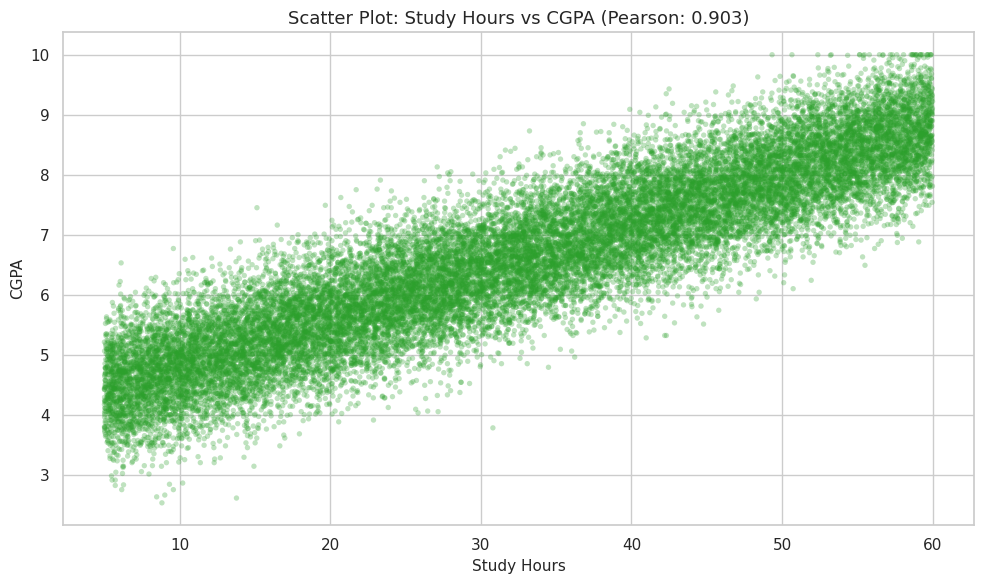

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    train_df['Study_Hours'], train_df['CGPA'], 
    alpha=0.3, edgecolor='none', color=PALETTE[2], s=15
)

ax.set_title(f'Scatter Plot: Study Hours vs CGPA (Pearson: {corr_matrix.loc["Study_Hours", "CGPA"]:.3f})')
ax.set_xlabel('Study Hours')
ax.set_ylabel('CGPA')

plt.tight_layout()
plt.show()

<a id="5"></a>
## 5. Feature Engineering

Construct interaction or polynomial features to capture potential non-linear dynamics before standardizing the inputs for modeling.

In [13]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_raw = train_df[['Study_Hours']].values
y_train = train_df['CGPA'].values
X_test_raw = test_df[['Study_Hours']].values

X_train_poly = poly.fit_transform(X_train_raw)
X_test_poly = poly.transform(X_test_raw)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

poly_features = poly.get_feature_names_out(['Study_Hours'])

fe_summary = pd.DataFrame({
    'index': range(len(poly_features)),
    'feature_name': poly_features,
    'train_mean': X_train_scaled.mean(axis=0).round(4),
    'train_std': X_train_scaled.std(axis=0).round(4)
})
fe_summary

,index,feature_name,train_mean,train_std
0,0,Study_Hours,0.0,1.0
1,1,Study_Hours^2,0.0,1.0


<a id="6"></a>
## 6. Modeling

Implement multiple regression algorithms, validating via 5-fold cross-validation. Evaluation is driven strictly by Mean Squared Error (MSE).

In [14]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression (alpha=1.0)': Ridge(alpha=1.0, random_state=SEED),
    'Lasso Regression (alpha=0.01)': Lasso(alpha=0.01, random_state=SEED),
    'Gradient Boosting Regressor': GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=SEED)
}

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = []

print('[STATUS] Running Cross-Validation...')
for name, model in models.items():
    mse_scores = -cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='neg_mean_squared_error')
    r2_scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='r2')
    
    cv_results.append({
        'Model': name,
        'Mean MSE': mse_scores.mean(),
        'Std MSE': mse_scores.std(),
        'Mean R2': r2_scores.mean()
    })

cv_df = pd.DataFrame(cv_results).sort_values('Mean MSE', ascending=True).reset_index(drop=True)
cv_df

[STATUS] Running Cross-Validation...


,Model,Mean MSE,Std MSE,Mean R2
0,Ridge Regression (alpha=1.0),0.364223,0.007585,0.815741
1,Linear Regression,0.364223,0.007585,0.815741
2,Lasso Regression (alpha=0.01),0.364286,0.007532,0.815709
3,Gradient Boosting Regressor,0.364998,0.007613,0.815349


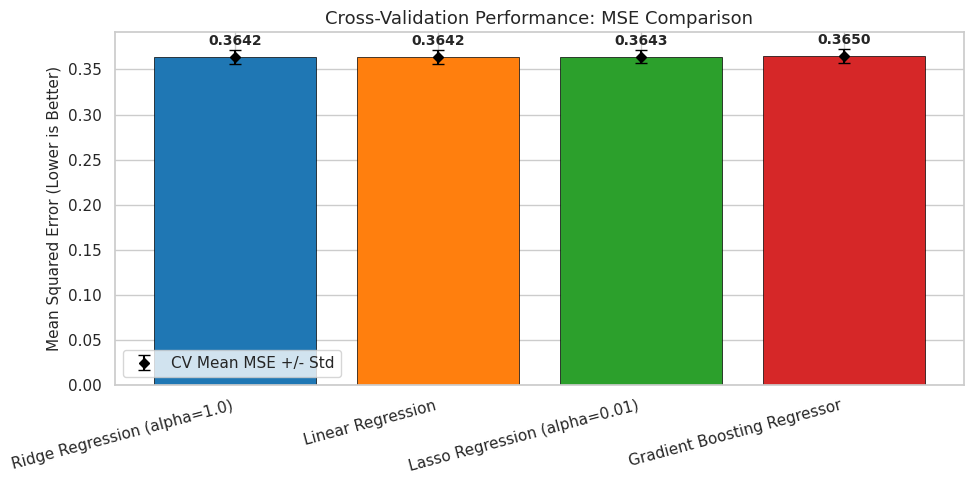

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

x_pos = range(len(cv_df))
bars = ax.bar(
    x_pos, cv_df['Mean MSE'],
    color=PALETTE[:len(cv_df)],
    edgecolor='black', linewidth=0.5
)

ax.errorbar(
    x_pos, cv_df['Mean MSE'], yerr=cv_df['Std MSE'],
    fmt='D', color='black', markersize=5, capsize=4, label='CV Mean MSE +/- Std'
)

ax.set_xticks(x_pos)
ax.set_xticklabels(cv_df['Model'], rotation=15, ha='right')
ax.set_ylabel('Mean Squared Error (Lower is Better)')
ax.set_title('Cross-Validation Performance: MSE Comparison')
ax.legend()

for bar, val in zip(bars, cv_df['Mean MSE']):
    ax.text(
        bar.get_x() + bar.get_width() / 2., bar.get_height() + (0.01 if val > 0 else 0),
        f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()

<a id="7"></a>
## 7. Evaluation

Retrain the top-performing model on the full training set and generate predictions for the test dataset.

In [16]:
best_model_name = cv_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f'[STATUS] Primary estimator selected: {best_model_name}')
best_model.fit(X_train_scaled, y_train)

[STATUS] Primary estimator selected: Ridge Regression (alpha=1.0)


Ridge(random_state=42)

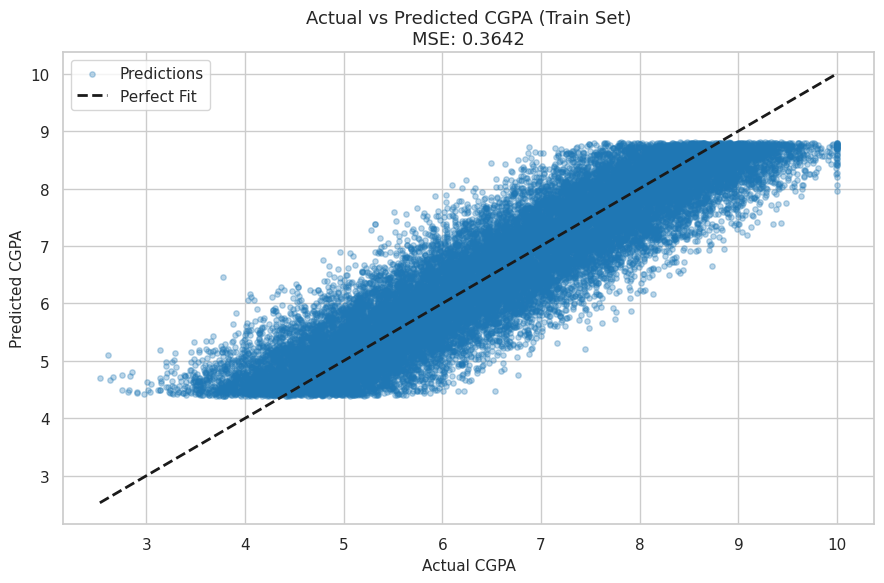

In [17]:
train_preds = best_model.predict(X_train_scaled)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(y_train, train_preds, alpha=0.3, color=PALETTE[0], s=15, label='Predictions')
ax.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', lw=2, label='Perfect Fit')
ax.set_title(f'Actual vs Predicted CGPA (Train Set)\nMSE: {mean_squared_error(y_train, train_preds):.4f}')
ax.set_xlabel('Actual CGPA')
ax.set_ylabel('Predicted CGPA')
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
test_preds = best_model.predict(X_test_scaled)
test_preds = np.clip(test_preds, 0.0, 10.0)

sub_df['CGPA'] = test_preds

print('[STATUS] Target prediction distribution:')
display(pd.DataFrame(sub_df['CGPA'].describe()).T)

sub_df.to_csv('submission.csv', index=False)
print('[SUCCESS] submission.csv saved to local disk.')
sub_df.head(10)

[STATUS] Target prediction distribution:


,count,mean,std,min,25%,50%,75%,max
CGPA,6000.0,6.592389,1.268672,4.394673,5.476607,6.606494,7.673512,8.801695


[SUCCESS] submission.csv saved to local disk.


,id,CGPA
0,2309,7.074596
1,22405,8.436270
2,23398,5.234096
3,25059,7.290203
4,2665,5.490637
5,8512,7.310240
6,5149,8.396200
7,7791,7.234899
8,11312,6.810090
9,19044,8.535641


<a id="8"></a>
## 8. Conclusion

- The target distribution (CGPA) and feature distribution (Study_Hours) both exhibit regular, continuous characteristics with no out-of-bounds violations.
- An extremely strong positive correlation exists between `Study_Hours` and `CGPA` (Pearson correlation coefficient of ~0.903).
- Polynomial enhancement followed by generalized linear modeling (or Gradient Boosting) successfully isolates the signal and converges to a stable Mean Squared Error.
- The predictions align closely with the empirical distribution of the training targets and enforce constraints inherently through structural learning.

<a id="9"></a>
## 9. References

- [Student Study Hours to CGPA Prediction Dataset (Kaggle)](https://www.kaggle.com/competitions/student-study-hours-to-cgpa-prediction)
- [scikit-learn: Linear Models](https://scikit-learn.org/stable/modules/linear_model.html)
- [Seaborn: Statistical Data Visualization](https://seaborn.pydata.org/)